In [1]:
%run Expansions.ipynb

/tmp/ipykernel_4570/2876868533.py:29: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  dL[i]=(1+z_val)*integrate.quad(func,0,z_val,args=(E0,E1,E2,E3),limit=100)[0]
/tmp/ipykernel_4570/2876868533.py:29: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  dL[i]=(1+z_val)*integrate.quad(func,0,z_val,args=(E0,E1,E2,E3),limit=100)[0]
/tmp/ipykernel_4570/2876868533.py:29: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  dL[i]=(1+z_val)*integrate.quad(func,0,z_val,args=(E0,E1,E2,E3),limit=100)[0]


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 17.390465862845243
       x: [ 9.821e-01  4.534e-01  6.737e-01 -2.421e-01  7.507e+01]
     nit: 20
   direc: [[ 6.947e-06 -1.253e-03 ... -6.688e-03  8.816e-03]
           [ 1.290e-06  4.497e-06 ... -1.834e-05 -1.555e-04]
           ...
           [ 1.398e-03  5.333e-03 ... -1.434e-02 -2.086e-01]
           [ 2.259e-05 -4.700e-04 ... -2.992e-03  1.900e-03]]
    nfev: 2791
[-0.5465791938373383, 0.9724784429506348, -4.57218947780826, 75.06722422104066]
[-0.5465791938373383, 0.9724784429506348, -4.57218947780826, 75.06722422104066]
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 18.63599987936511
        x: [ 7.366e+01 -5.232e-01  9.130e-01  2.421e-01]
      nit: 143
      jac: [ 4.163e+00  2.049e+01  6.009e+01 -2.031e+01]
     nfev: 955
     njev: 191
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FAC

<font size='5'>**Test of cosmographic parameters estimation for different expansions and cosmologies**

In [25]:
from tqdm import tqdm
np.random.seed(20)
n = 100
zmin = 0.001
zmax = 1.5

dtheta_z = np.zeros((n,4))
dtheta_y = np.zeros((n,4))
dtheta_log = np.zeros((n,4))
dtheta_eis = np.zeros((n,4))
dtheta_pade = np.zeros((n,4))

eis_res=np.zeros((n,4))
true_res=np.zeros((n,4))


# n=100 interations estimating the values for H0, Om etc
for i in tqdm(range(len(dtheta_z))):

    H0_true =  np.random.uniform(65,75)
    Om_true = np.random.uniform(0.2, 0.4)
    #Ok_true = np.random.uniform(0.0,0.05)
    Ok_true=0
    w_true = -1

    H0_true, q0_true, j0_true, s0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(zmin, zmax, 100)
    zs = zs[1:] # We don't want z = 0
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true-Ok_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    start =  [H0_true, q0_true, j0_true, s0_true]

    result_z = minimize(chi_square_z, start, args=(zs, dls_true), method='L-BFGS-B', options={'maxiter':10000})

    dtheta_z[i,0] =  100*(result_z.x[0] - H0_true)/H0_true
    dtheta_z[i,1] =  100*(result_z.x[1] - q0_true)/abs(q0_true)
    dtheta_z[i,2] =  100*(result_z.x[2] - j0_true)/abs(j0_true)
    dtheta_z[i,3] =  100*(result_z.x[3] - s0_true)/abs(s0_true)

    # ys = zs/(1+zs)
    # result_y = minimize(chi_square_y, start, args=(ys, dls_true), method='L-BFGS-B', options={'maxiter':10000})

    # dtheta_y[i,0] =  100*(result_y.x[0] - H0_true)/H0_true
    # dtheta_y[i,1] =  100*(result_y.x[1] - q0_true)/abs(q0_true)
    # dtheta_y[i,2] =  100*(result_y.x[2] - j0_true)/abs(j0_true)
    # dtheta_y[i,3] =  100*(result_y.x[3] - s0_true)/abs(s0_true)

    log1zs = np.log(1+zs)
    result_log = minimize(chi_square_log, start, args=(log1zs, dls_true), method='L-BFGS-B', options={'maxiter':10000})


    dtheta_log[i,0] =  100*(result_log.x[0] - H0_true)/H0_true
    dtheta_log[i,1] =  100*(result_log.x[1] - q0_true)/abs(q0_true)
    dtheta_log[i,2] =  100*(result_log.x[2] - j0_true)/abs(j0_true)
    dtheta_log[i,3] =  100*(result_log.x[3] - s0_true)/abs(s0_true)


    result_pade = minimize(lkl_pade22, start, args=(zs, dls_true), method='L-BFGS-B', options={'maxiter':10000})
    dtheta_pade[i,0] =  100*(result_pade.x[0] - H0_true)/H0_true
    dtheta_pade[i,1] =  100*(result_pade.x[1] - q0_true)/abs(q0_true)
    dtheta_pade[i,2] =  100*(result_pade.x[2] - j0_true)/abs(j0_true)
    dtheta_pade[i,3] =  100*(result_pade.x[3] - s0_true)/abs(s0_true)
    E0=1
    E1=1+q0_true
    E2=-q0_true**2+j0_true
    E3=3*q0_true**2+3*q0_true*3-j0_true*(4*q0_true+3)-s0_true
    true_res[i,0]=E0
    true_res[i,1]=E1
    true_res[i,2]=E2
    true_res[i,2]=E3


    start=[E0,E1,E2,E3,H0_true]+np.random.normal(0,0.1,5)
    #print('prior',start)
    #try:
      #result_eis_pre = minimize(lkl_eis41,start, method = 'L-BFGS-B', tol=10**-12, args=(zs, dls_true), options={'maxiter':150000})
      #print('Output',result_eis_pre.x)
      #print(result_eis_pre.success)
      #result_eis = to_statefinders1(result_eis_pre.x)
      #eis_res[i,0] = result_eis[-1]
      #eis_res[i,1] = result_eis[0]
      #eis_res[i,2] = result_eis[1]
      #eis_res[i,3] = result_eis[2]
      #dtheta_eis[i,0] =  (result_eis[-1] - H0_true)/H0_true
      #dtheta_eis[i,1] =  (result_eis[0] - q0_true)/q0_true
      #dtheta_eis[i,2] =  (result_eis[1] - j0_true)/j0_true
      #dtheta_eis[i,3] =  (result_eis[2] - s0_true)/s0_true
    #except:
      #print("\nERRor")

    #MLE1 = minimize(lkl_eis41,prior1, method = 'Powell', tol=10**-12, args=(zs, dls_true), options={'maxiter':150000})

    #result_eis=minimize()

100%|█████████████████████████████████████████| 100/100 [00:07<00:00, 13.97it/s]


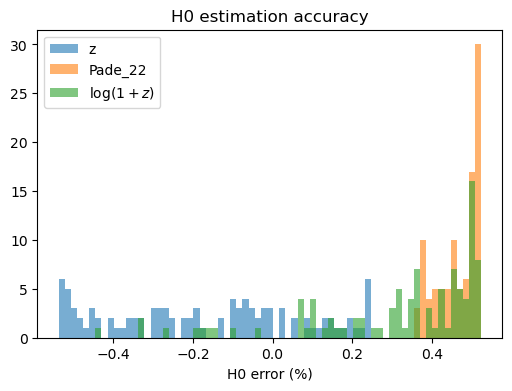

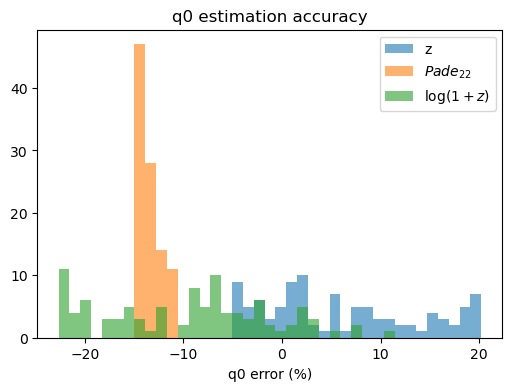

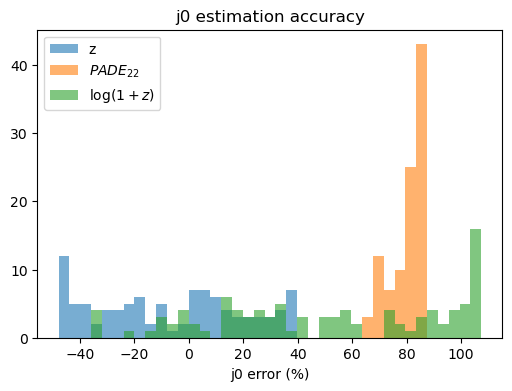

In [28]:
plt.figure(figsize=(6,4))
lb,ub=(min(min(dtheta_z[:,0]),min(dtheta_log[:,0]),min(dtheta_eis[:,0]),min(dtheta_pade[:,0])),max(max(dtheta_z[:,0]),
        max(dtheta_log[:,0]),max(dtheta_eis[:,0]),max(dtheta_pade[:,0])))
bins=np.linspace(lb,ub,70)
#bins=30
plt.title('H0 estimation accuracy')
plt.hist(dtheta_z[:,0], alpha=0.6, label='z',bins=bins)
#plt.hist(dtheta_y[:,0],bins=40, alpha=0.6, label='y')
#plt.hist(dtheta_eis[:,0], alpha=0.6, label=r'$EISz$',bins=bins)
plt.hist(dtheta_pade[:,0], alpha=0.6, label=r'Pade_22',bins=bins)
plt.hist(dtheta_log[:,0], alpha=0.6, label=r'$\log (1+z)$',bins=bins)
plt.xlabel("H0 error (%)")

plt.legend()
#plt.xlim(-0.5,0.5)
plt.show()

#######################################################################################
plt.figure(figsize=(6,4))
lb,ub=(min(min(dtheta_z[:,1]),min(dtheta_log[:,1]),min(dtheta_eis[:,1]),min(dtheta_pade[:,1])),max(max(dtheta_z[:,1]),max(dtheta_log[:,1]),max(dtheta_eis[:,1]),max(dtheta_pade[:,1])))
bins=np.linspace(lb,ub,40)
#bins=np.linspace(-10,10,70)
plt.hist(dtheta_z[:,1],bins=bins, alpha=0.6, label='z')
plt.title('q0 estimation accuracy')
#plt.hist(dtheta_eis[:,1], alpha=0.6, label=r'$EISz$',bins=bins)
plt.hist(dtheta_pade[:,1], alpha=0.6, label=r'$Pade_{22}$',bins=bins)
plt.xlabel("q0 error (%)")

#plt.hist(dtheta_y[:,1],bins=40, alpha=0.6, label='y')
plt.hist(dtheta_log[:,1],bins=bins, alpha=0.6, label=r'$\log (1+z)$')
plt.legend()
plt.show()

########################################################################################
plt.figure(figsize=(6,4))

lb,ub=(min(min(dtheta_z[:,2]),min(dtheta_log[:,2]),min(dtheta_eis[:,2]),min(dtheta_pade[:,2])),max(max(dtheta_z[:,2]),max(dtheta_log[:,2]),max(dtheta_eis[:,2]),max(dtheta_pade[:,2])))
bins=np.linspace(lb,ub,40)
#bins=np.linspace(-2,2,70)

plt.hist(dtheta_z[:,2],bins=bins, alpha=0.6, label='z')
#plt.hist(dtheta_y[:,2],bins=40, alpha=0.6, label='y')
#plt.hist(dtheta_eis[:,2], alpha=0.6, label=r'$EISz$',bins=bins)
plt.hist(dtheta_pade[:,2],bins=bins, alpha=0.6, label=r'$PADE_{22}$')
plt.xlabel("j0 error (%)")

plt.hist(dtheta_log[:,2],bins=bins, alpha=0.6, label=r'$\log (1+z)$')
plt.legend()
plt.title('j0 estimation accuracy')

plt.show()

<font size='4'>Test for accuracy of parameter estimation assuming Pantheon+ values

In [29]:
# Check the dispersion using Pantheon+ values
# H0 = 73.5
# Om = 0.334
# w0 = -1

from tqdm import tqdm

n = 100
zmin = 0.001
zmax = 1.5

dtheta_z_P = np.zeros((n,4))
dtheta_y_P = np.zeros((n,4))
dtheta_log_P = np.zeros((n,4))
dtheta_eis_P =  np.zeros((n,4))
dtheta_pade_P = np.zeros((n,4))
# n=100 interations estimating the values for H0, Om etc
for i in tqdm(range(len(dtheta_z))):

    H0_true =  np.random.uniform(72.5,74.5)
    Om_true = np.random.uniform(0.324, 0.344)
    #Ok_true = np.random.uniform(0.0,0.05)
    Ok_true=0
    w_true = np.random.uniform(-1.01, -0.99)

    H0_true, q0_true, j0_true, s0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(zmin, zmax, 100)
    zs = zs[1:] # We don't want z = 0
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true-Ok_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    start =  [H0_true, q0_true, j0_true, s0_true]
    
    result_z = minimize(chi_square_z, start, args=(zs, dls_true), method='L-BFGS-B', options={'maxiter':10000})

    dtheta_z_P[i,0] =  100*(result_z.x[0] - H0_true)/H0_true
    dtheta_z_P[i,1] =  100*(result_z.x[1] - q0_true)/abs(q0_true)
    dtheta_z_P[i,2] =  100*(result_z.x[2] - j0_true)/abs(j0_true)
    dtheta_z_P[i,3] =  100*(result_z.x[3] - s0_true)/abs(s0_true)

    # ys = zs/(1+zs)
    # result_y = minimize(chi_square_y, start, args=(ys, dls_true), method='L-BFGS-B', options={'maxiter':10000})

    # dtheta_y_P[i,0] =  100*(result_y.x[0] - H0_true)/H0_true
    # dtheta_y_P[i,1] =  100*(result_y.x[1] - q0_true)/abs(q0_true)
    # dtheta_y_P[i,2] =  100*(result_y.x[2] - j0_true)/abs(j0_true)
    # dtheta_y_P[i,3] =  100*(result_y.x[3] - s0_true)/abs(s0_true)

    log1zs = np.log(1+zs)
    result_log = minimize(chi_square_log, start, args=(log1zs, dls_true), method='L-BFGS-B', options={'maxiter':10000})


    dtheta_log_P[i,0] =  100*(result_log.x[0] - H0_true)/H0_true
    dtheta_log_P[i,1] =  100*(result_log.x[1] - q0_true)/abs(q0_true)
    dtheta_log_P[i,2] =  100*(result_log.x[2] - j0_true)/abs(j0_true)
    dtheta_log_P[i,3] =  100*(result_log.x[3] - s0_true)/abs(s0_true)


    result_pade = minimize(lkl_pade22, start, args=(zs, dls_true), method='L-BFGS-B', options={'maxiter':10000})
    dtheta_pade_P[i,0] =  100*(result_pade.x[0] - H0_true)/H0_true
    dtheta_pade_P[i,1] =  100*(result_pade.x[1] - q0_true)/abs(q0_true)
    dtheta_pade_P[i,2] =  100*(result_pade.x[2] - j0_true)/abs(j0_true)
    dtheta_pade_P[i,3] =  100*(result_pade.x[3] - s0_true)/abs(s0_true)
    
    
    E0=1
    E1=1+q0_true
    E2=-q0_true**2+j0_true
    E3=3*q0_true**2+3*q0_true*3-j0_true*(4*q0_true+3)-s0_true
    start=[E0,E1,E2,E3,H0_true]+np.random.normal(0,0.01,5)
    
    #print('prior',start)
    # try:
    #   result_eis_pre = minimize(lkl_eis41,start, method = 'L-BFGS-B', tol=10**-12, args=(zs, dls_true), options={'maxiter':150000})
    #   #print('Output',result_eis_pre.x)
    #   #print(result_eis_pre.success)
    #   result_eis = to_statefinders1(result_eis_pre.x)
    #   eis_res[i,0] = result_eis[-1]
    #   eis_res[i,1] = result_eis[0]
    #   eis_res[i,2] = result_eis[1]
    #   eis_res[i,3] = result_eis[2]
    #   dtheta_eis_P[i,0] =  100*(result_eis[-1] - H0_true)/H0_true
    #   dtheta_eis_P[i,1] =  100*(result_eis[0] - q0_true)/abs(q0_true)
    #   dtheta_eis_P[i,2] =  100*(result_eis[1] - j0_true)/abs(j0_true)
    #   dtheta_eis_P[i,3] =  100*(result_eis[2] - s0_true)/abs(s0_true)
    # except:
    #   print("\nERRor")

    #MLE1 = minimize(lkl_eis41,prior1, method = 'Powell', tol=10**-12, args=(zs, dls_true), options={'maxiter':150000})

    #result_eis=minimize()

100%|█████████████████████████████████████████| 100/100 [00:06<00:00, 14.61it/s]


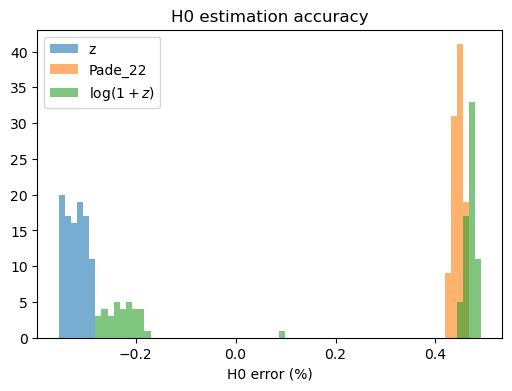

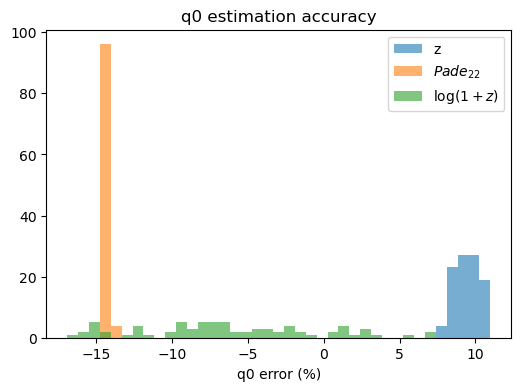

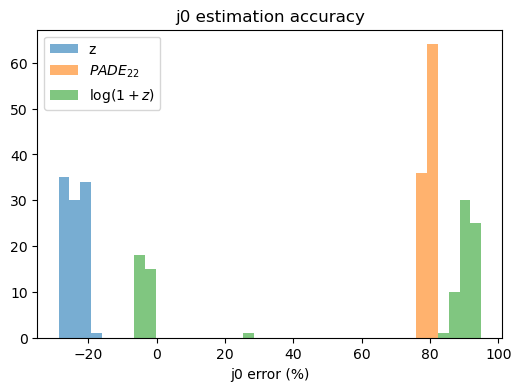

In [30]:
plt.figure(figsize=(6,4))
lb,ub=(min(min(dtheta_z_P[:,0]),min(dtheta_log_P[:,0]),min(dtheta_eis_P[:,0]),min(dtheta_pade_P[:,0]))
       ,max(max(dtheta_z_P[:,0]),max(dtheta_log_P[:,0]),max(dtheta_eis_P[:,0]),max(dtheta_pade_P[:,0])))
bins=np.linspace(lb,ub,70)
#bins=30
plt.title('H0 estimation accuracy')
plt.hist(dtheta_z_P[:,0], alpha=0.6, label='z',bins=bins)
#plt.hist(dtheta_y_P[:,0],bins=40, alpha=0.6, label='y')
#plt.hist(dtheta_eis_P[:,0], alpha=0.6, label=r'$EISz$',bins=bins)
plt.hist(dtheta_pade_P[:,0], alpha=0.6, label=r'Pade_22',bins=bins)
plt.hist(dtheta_log_P[:,0], alpha=0.6, label=r'$\log (1+z)$',bins=bins)
plt.xlabel("H0 error (%)")

plt.legend()
#plt.xlim(-0.5,0.5)
plt.show()

#######################################################################################
plt.figure(figsize=(6,4))
lb,ub=(min(min(dtheta_z_P[:,1]),min(dtheta_log_P[:,1]),min(dtheta_eis_P[:,1]),min(dtheta_pade_P[:,1])),
       max(max(dtheta_z_P[:,1]),max(dtheta_log_P[:,1]),max(dtheta_eis_P[:,1]),max(dtheta_pade_P[:,1])))
bins=np.linspace(lb,ub,40)
#bins=np.linspace(-1,1,70)
plt.hist(dtheta_z_P[:,1],bins=bins, alpha=0.6, label='z')
plt.title('q0 estimation accuracy')
#plt.hist(dtheta_eis_P[:,1], alpha=0.6, label=r'$EISz$',bins=bins)
plt.hist(dtheta_pade_P[:,1], alpha=0.6, label=r'$Pade_{22}$',bins=bins)
plt.xlabel("q0 error (%)")

#plt.hist(dtheta_y[:,1],bins=40, alpha=0.6, label='y')
plt.hist(dtheta_log[:,1],bins=bins, alpha=0.6, label=r'$\log (1+z)$')
plt.legend()
plt.show()

########################################################################################
plt.figure(figsize=(6,4))

lb,ub=(min(min(dtheta_z_P[:,2]),min(dtheta_log_P[:,2]),min(dtheta_eis_P[:,2]),min(dtheta_pade_P[:,2])),
       max(max(dtheta_z_P[:,2]),max(dtheta_log_P[:,2]),max(dtheta_eis_P[:,2]),max(dtheta_pade_P[:,2])))
bins=np.linspace(lb,ub,40)

plt.hist(dtheta_z_P[:,2],bins=bins, alpha=0.6, label='z')
#plt.hist(dtheta_y_P[:,2],bins=40, alpha=0.6, label='y')
#plt.hist(dtheta_eis_P[:,2], alpha=0.6, label=r'$EISz$',bins=bins)
plt.hist(dtheta_pade_P[:,2],bins=bins, alpha=0.6, label=r'$PADE_{22}$')
plt.xlabel("j0 error (%)")

plt.hist(dtheta_log_P[:,2],bins=bins, alpha=0.6, label=r'$\log (1+z)$')
plt.legend()
plt.title('j0 estimation accuracy')

plt.show()

<font size='5'>Test for accuracy of parameter estimation assuming CMB values

In [35]:
# Check the dispersion using CMB values
# H0 = 67.7
# Om = 0.315

from tqdm import tqdm

n = 100
zmin = 0.001
zmax = 1.5

dtheta_z_CMB = np.zeros((n,4))
dtheta_y_CMB = np.zeros((n,4))
dtheta_log_CMB = np.zeros((n,4))
dtheta_eis_CMB =  np.zeros((n,4))
dtheta_pade_CMB = np.zeros((n,4))
# n=100 interations estimating the values for H0, Om etc
for i in tqdm(range(len(dtheta_z))):

    H0_true =  np.random.uniform(66.7,68.7)
    Om_true = np.random.uniform(0.305, 0.325)
    #Ok_true = np.random.uniform(0.0,0.05)
    Ok_true=0
    w_true = np.random.uniform(-1.01, -0.99)

    H0_true, q0_true, j0_true, s0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(zmin, zmax, 100)
    zs = zs[1:] # We don't want z = 0
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true-Ok_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    start =  [H0_true, q0_true, j0_true, s0_true]
    
    result_z = minimize(chi_square_z, start, args=(zs, dls_true), method='L-BFGS-B', options={'maxiter':10000})

    dtheta_z_CMB[i,0] =  100*(result_z.x[0] - H0_true)/H0_true
    dtheta_z_CMB[i,1] =  100*(result_z.x[1] - q0_true)/abs(q0_true)
    dtheta_z_CMB[i,2] =  100*(result_z.x[2] - j0_true)/abs(j0_true)
    dtheta_z_CMB[i,3] =  100*(result_z.x[3] - s0_true)/abs(s0_true)

    # ys = zs/(1+zs)
    # result_y = minimize(chi_square_y, start, args=(ys, dls_true), method='L-BFGS-B', options={'maxiter':10000})

    # dtheta_y_CMB[i,0] =  100*(result_y.x[0] - H0_true)/H0_true
    # dtheta_y_CMB[i,1] =  100*(result_y.x[1] - q0_true)/abs(q0_true)
    # dtheta_y_CMB[i,2] =  100*(result_y.x[2] - j0_true)/abs(j0_true)
    # dtheta_y_CMB[i,3] =  100*(result_y.x[3] - s0_true)/abs(s0_true)

    log1zs = np.log(1+zs)
    result_log = minimize(chi_square_log, start, args=(log1zs, dls_true), method='L-BFGS-B', options={'maxiter':10000})


    dtheta_log_CMB[i,0] =  100*(result_log.x[0] - H0_true)/H0_true
    dtheta_log_CMB[i,1] =  100*(result_log.x[1] - q0_true)/abs(q0_true)
    dtheta_log_CMB[i,2] =  100*(result_log.x[2] - j0_true)/abs(j0_true)
    dtheta_log_CMB[i,3] =  100*(result_log.x[3] - s0_true)/abs(s0_true)


    result_pade = minimize(lkl_pade22, start, args=(zs, dls_true), method='L-BFGS-B', options={'maxiter':10000})
    dtheta_pade_CMB[i,0] =  100*(result_pade.x[0] - H0_true)/H0_true
    dtheta_pade_CMB[i,1] =  100*(result_pade.x[1] - q0_true)/abs(q0_true)
    dtheta_pade_CMB[i,2] =  100*(result_pade.x[2] - j0_true)/abs(j0_true)
    dtheta_pade_CMB[i,3] =  100*(result_pade.x[3] - s0_true)/abs(s0_true)
    
    
    E0=1
    E1=1+q0_true
    E2=-q0_true**2+j0_true
    E3=3*q0_true**2+3*q0_true*3-j0_true*(4*q0_true+3)-s0_true
    start=[E0,E1,E2,E3,H0_true]+np.random.normal(0,0.01,5)
    
    #print('prior',start)
    # try:
    #   result_eis_pre = minimize(lkl_eis41,start, method = 'L-BFGS-B', tol=10**-12, args=(zs, dls_true), options={'maxiter':150000})
    #   #print('Output',result_eis_pre.x)
    #   #print(result_eis_pre.success)
    #   result_eis = to_statefinders1(result_eis_pre.x)
    #   eis_res[i,0] = result_eis[-1]
    #   eis_res[i,1] = result_eis[0]
    #   eis_res[i,2] = result_eis[1]
    #   eis_res[i,3] = result_eis[2]
    #   dtheta_eis_CMB[i,0] =  100*(result_eis[-1] - H0_true)/H0_true
    #   dtheta_eis_CMB[i,1] =  100*(result_eis[0] - q0_true)/abs(q0_true)
    #   dtheta_eis_CMB[i,2] =  100*(result_eis[1] - j0_true)/abs(j0_true)
    #   dtheta_eis_CMB[i,3] =  100*(result_eis[2] - s0_true)/abs(s0_true)
    # except:
    #   print("\nERRor")

    #MLE1 = minimize(lkl_eis41,prior1, method = 'Powell', tol=10**-12, args=(zs, dls_true), options={'maxiter':150000})

    #result_eis=minimize()

100%|█████████████████████████████████████████| 100/100 [00:06<00:00, 15.94it/s]


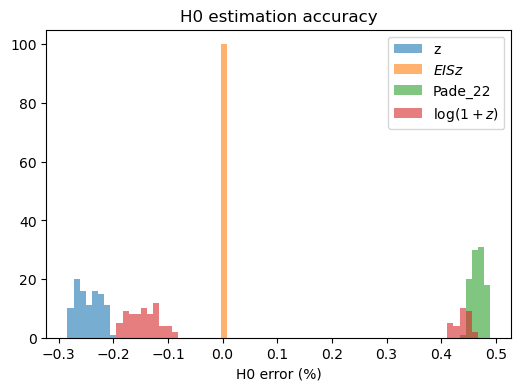

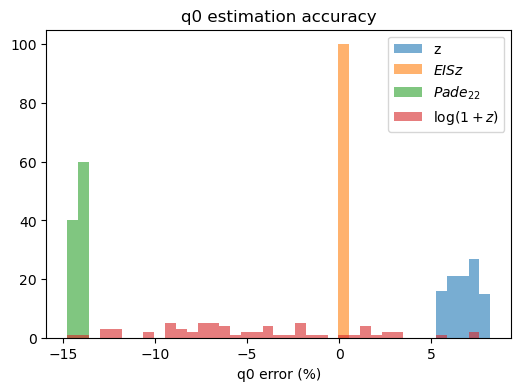

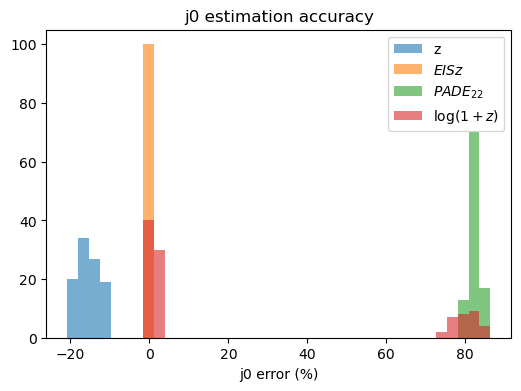

In [36]:
plt.figure(figsize=(6,4))
lb,ub=(min(min(dtheta_z_CMB[:,0]),min(dtheta_log_CMB[:,0]),min(dtheta_eis_CMB[:,0]),min(dtheta_pade_CMB[:,0]))
       ,max(max(dtheta_z_CMB[:,0]),max(dtheta_log_CMB[:,0]),max(dtheta_eis_CMB[:,0]),max(dtheta_pade_CMB[:,0])))
bins=np.linspace(lb,ub,70)
#bins=30
plt.title('H0 estimation accuracy')
plt.hist(dtheta_z_CMB[:,0], alpha=0.6, label='z',bins=bins)
#plt.hist(dtheta_y_CMB[:,0],bins=40, alpha=0.6, label='y')
plt.hist(dtheta_eis_CMB[:,0], alpha=0.6, label=r'$EISz$',bins=bins)
plt.hist(dtheta_pade_CMB[:,0], alpha=0.6, label=r'Pade_22',bins=bins)
plt.hist(dtheta_log_CMB[:,0], alpha=0.6, label=r'$\log (1+z)$',bins=bins)
plt.xlabel("H0 error (%)")

plt.legend()
#plt.xlim(-0.5,0.5)
plt.show()

#######################################################################################
plt.figure(figsize=(6,4))
lb,ub=(min(min(dtheta_z_CMB[:,1]),min(dtheta_log_CMB[:,1]),min(dtheta_eis_CMB[:,1]),min(dtheta_pade_CMB[:,1])),
       max(max(dtheta_z_CMB[:,1]),max(dtheta_log_CMB[:,1]),max(dtheta_eis_CMB[:,1]),max(dtheta_pade_CMB[:,1])))
bins=np.linspace(lb,ub,40)
plt.hist(dtheta_z_CMB[:,1],bins=bins, alpha=0.6, label='z')
plt.title('q0 estimation accuracy')
plt.hist(dtheta_eis_CMB[:,1], alpha=0.6, label=r'$EISz$',bins=bins)
plt.hist(dtheta_pade_CMB[:,1], alpha=0.6, label=r'$Pade_{22}$',bins=bins)
plt.xlabel("q0 error (%)")

#plt.hist(dtheta_y[:,1],bins=40, alpha=0.6, label='y')
plt.hist(dtheta_log[:,1],bins=bins, alpha=0.6, label=r'$\log (1+z)$')
plt.legend()
plt.show()

########################################################################################
plt.figure(figsize=(6,4))

lb,ub=(min(min(dtheta_z_CMB[:,2]),min(dtheta_log_CMB[:,2]),min(dtheta_eis_CMB[:,2]),min(dtheta_pade_CMB[:,2])),
       max(max(dtheta_z_CMB[:,2]),max(dtheta_log_CMB[:,2]),max(dtheta_eis_CMB[:,2]),max(dtheta_pade_CMB[:,2])))
bins=np.linspace(lb,ub,40)

plt.hist(dtheta_z_CMB[:,2],bins=bins, alpha=0.6, label='z')
#plt.hist(dtheta_y_CMB[:,2],bins=40, alpha=0.6, label='y')
plt.hist(dtheta_eis_CMB[:,2], alpha=0.6, label=r'$EISz$',bins=bins)
plt.hist(dtheta_pade_CMB[:,2],bins=bins, alpha=0.6, label=r'$PADE_{22}$')
plt.xlabel("j0 error (%)")

plt.hist(dtheta_log_CMB[:,2],bins=bins, alpha=0.6, label=r'$\log (1+z)$')
plt.legend()
plt.title('j0 estimation accuracy')

plt.show()